In [ ]:
# Mounting Google Drive to Read Excel File
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/ALP-1/digital_wallet_ltv_dataset_Excel.xlsx'

In [ ]:
# Load the Excel file
df = pd.read_excel(file_path, sheet_name='digital_wallet_ltv_dataset')
# Display the first few rows
df.head()

,Customer_ID,Age,Location,Income_Level,Total_Transactions,Avg_Transaction_Value of user in rupees,Max_Transaction_Value in rupees,Min_Transaction_Value in rupees,Total_Spent in rupees,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,App_Usage_Frequency,Preferred_Payment_Method,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
0,cust_0000,54,Urban,Low,192,16736.384023,60216.834510,6525.814861,3.213386e+06,140,209,2114,25,2224.012140,Monthly,Debit Card,3,61.568590,1,3.279546e+05
1,cust_0001,67,Suburban,High,979,14536.734683,48350.100272,2186.742245,1.423146e+07,229,240,2960,20,4026.823518,Monthly,UPI,17,60.392889,8,1.437053e+06
2,cust_0002,44,Urban,High,329,7061.372800,32521.157187,2743.406808,2.323192e+06,73,21,3170,0,1441.011395,Monthly,Debit Card,11,45.305579,4,2.419387e+05
3,cust_0003,30,Rural,High,71,16426.876453,17827.896720,4360.784994,1.166308e+06,299,285,4756,35,4365.855580,Weekly,Wallet Balance,6,22.030191,1,1.284599e+05
4,cust_0004,58,Urban,Middle,878,10800.092660,17497.634534,4532.872520,9.482481e+06,236,329,1992,18,4161.523827,Daily,UPI,18,20.634723,5,9.569514e+05


In [ ]:
###Checking Dataframe is completely loaded or not:
print(f"Number of Rows: {df.shape[0]}")   #-----------#[0] refers to rows--without including row with column headings
print(f"Number of Columns: {df.shape[1]}") #-----------#[1] refers to columns

Number of Rows: 7000
Number of Columns: 20


In [ ]:
###Missing Values Check in all columns
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Customer_ID                                0
Age                                        0
Location                                   0
Income_Level                               0
Total_Transactions                         0
Avg_Transaction_Value of user in rupees    0
Max_Transaction_Value in rupees            0
Min_Transaction_Value in rupees            0
Total_Spent in rupees                      0
Active_Days                                0
Last_Transaction_Days_Ago                  0
Loyalty_Points_Earned                      0
Referral_Count                             0
Cashback_Received                          0
App_Usage_Frequency                        0
Preferred_Payment_Method                   0
Support_Tickets_Raised                     0
Issue_Resolution_Time                      0
Customer_Satisfaction_Score                0
LTV                                        0
dtype: int64


In [ ]:
### Its fortunate that the dataset is completed fully and has no missing values
# If it did we would have to handle with forward fill/ backward fill/ moving average/ a interpolation technique
# / Zero the missing values / Delete row items

In [ ]:
### Descriptive Stats----Numeric variables
numeric_summary = df.describe().loc[['min', 'mean', 'max']]   #---.describe knows to only work for numeric columns by default
print(numeric_summary)                                                              #--- and .loc allows us to restrict output to min,max,avg

            Age  Total_Transactions  Avg_Transaction_Value of user in rupees  \
min   16.000000            1.000000                                10.185827   
mean  42.633714          501.221429                              9946.831482   
max   69.000000         1000.000000                             19996.445086   

      Max_Transaction_Value in rupees  Min_Transaction_Value in rupees  \
min                         31.857484                         4.617966   
mean                     30159.596784                      2981.549953   
max                      98809.241533                      9917.028823   

      Total_Spent in rupees  Active_Days  Last_Transaction_Days_Ago  \
min            1.498144e+03     1.000000                   1.000000   
mean           5.002022e+06   181.934857                 183.847714   
max            1.946773e+07   365.000000                 365.000000   

      Loyalty_Points_Earned  Referral_Count  Cashback_Received  \
min                0.000000    

In [ ]:
### Descriptive Stats----Categoric variables
#Finding Categorical Columns and Counting number of Unique Categories
categorical_columns = df.select_dtypes(include=['object']).columns

print("Categorical Columns - Unique Values:\n")
for col in categorical_columns:
    if col != "Customer_ID":
        print(f"🟦 {col} → {df[col].nunique()} unique values")
        print(df[col].unique())
        print("-" * 50)

Categorical Columns - Unique Values:

🟦 Location → 3 unique values
['Urban' 'Suburban' 'Rural']
--------------------------------------------------
🟦 Income_Level → 3 unique values
['Low' 'High' 'Middle']
--------------------------------------------------
🟦 App_Usage_Frequency → 3 unique values
['Monthly' 'Weekly' 'Daily']
--------------------------------------------------
🟦 Preferred_Payment_Method → 4 unique values
['Debit Card' 'UPI' 'Wallet Balance' 'Credit Card']
--------------------------------------------------


In [ ]:
## We can see "Customer ID" is also categorical with alphabets in it, But its obvious that there are 7000 unique values
## as each row denotes a different customer.

In [ ]:
#Dropping a sureshot non-informative column
df_model = df.drop(columns=['Customer_ID'])
df_model.head(3)

,Age,Location,Income_Level,Total_Transactions,Avg_Transaction_Value of user in rupees,Max_Transaction_Value in rupees,Min_Transaction_Value in rupees,Total_Spent in rupees,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,App_Usage_Frequency,Preferred_Payment_Method,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
0,54,Urban,Low,192,16736.384023,60216.834510,6525.814861,3.213386e+06,140,209,2114,25,2224.012140,Monthly,Debit Card,3,61.568590,1,3.279546e+05
1,67,Suburban,High,979,14536.734683,48350.100272,2186.742245,1.423146e+07,229,240,2960,20,4026.823518,Monthly,UPI,17,60.392889,8,1.437053e+06
2,44,Urban,High,329,7061.372800,32521.157187,2743.406808,2.323192e+06,73,21,3170,0,1441.011395,Monthly,Debit Card,11,45.305579,4,2.419387e+05


In [ ]:
### Before Feature enginerring, Encoding etc I belive its better to exploratory analysis(EDA) on the data to understad
### Relationships between features, Outliers, Distribution of values,Potential multicollinearity

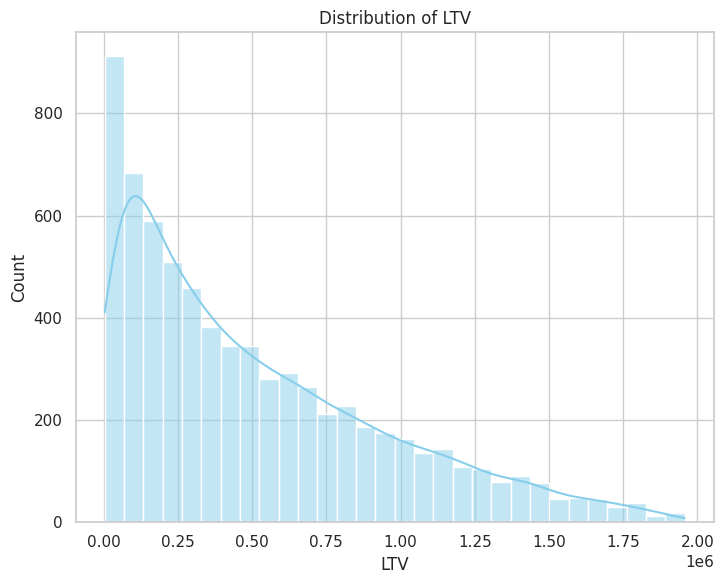

In [ ]:
#1) Distribution of LTV

import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['LTV'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of LTV')

plt.tight_layout()
plt.show()

In [ ]:
## INFERENCE:
# Most users are low to medium spenders, but a small group contributes significantly more.
# i.e-----> Majority of customers have low to moderate LTV (0–5,00,000) Very few customers fall in the high-value LTV range (15,00,000+)
# Outliers should be kept for LTV prediction — they represent real and valuable customers.
# Scaling will be essential for clustering  as K-means is sensitive to large value ranges.


#consider a log transform on LTV (optional) if there are model performance issues in Linear Regression

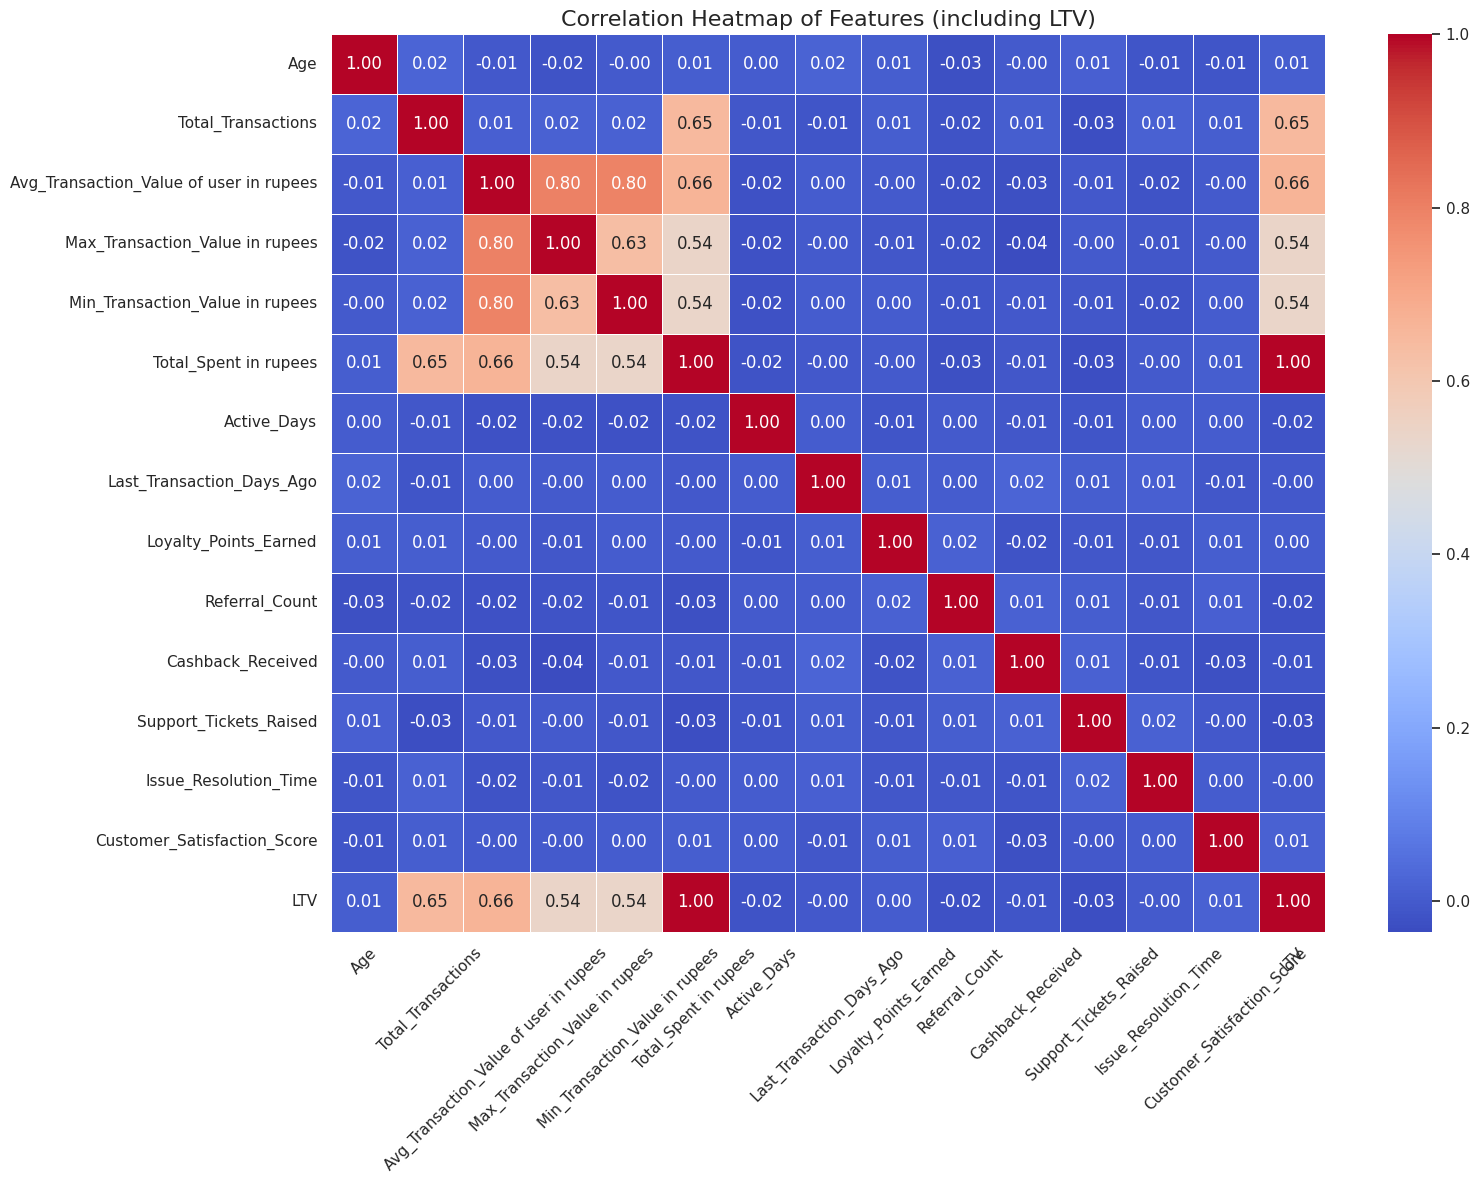

In [ ]:
## Co-relation Heatmap for numerical variables only in PANDAS--------The .corr fucntion ignores all categorical variables default

# Correlation Matrix
plt.figure(figsize=(16, 12))

# Compute correlation matrix
corr_matrix = df_model.corr(numeric_only=True)

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Features (including LTV)', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
## To analyse heatmap:
# Values close to +1 or -1 = Strong correlation
# Check column and row of LTV to see which has good/bad co-relation
# Check features for multi-colinearity

In [ ]:
## Adding possible new features if they can add predictive power to the model
# 'Customer_Tenure_Months'
# 'Spending_Per_Day'
# Spending_Recency_Ratio'
# 'Transaction_Range'

# Create new derived features
df_model['Customer_Tenure_Months'] = df_model['Active_Days'] / 30
df_model['Spending_Per_Day'] = df_model['Total_Spent in rupees'] / df_model['Active_Days']
df_model['Spending_Recency_Ratio'] = df_model['Total_Spent in rupees'] / (df_model['Last_Transaction_Days_Ago'] + 1)
df_model['Transaction_Range'] = df_model['Max_Transaction_Value in rupees'] - df_model['Min_Transaction_Value in rupees']

#Sample display
df_model[['Customer_Tenure_Months', 'Spending_Per_Day', 'Spending_Recency_Ratio', 'Transaction_Range']].head(3)

,Customer_Tenure_Months,Spending_Per_Day,Spending_Recency_Ratio,Transaction_Range
0,4.666667,22952.755232,15301.836821,53691.019649
1,7.633333,62146.127749,59051.714749,46163.358027
2,2.433333,31824.543168,105599.620512,29777.750379


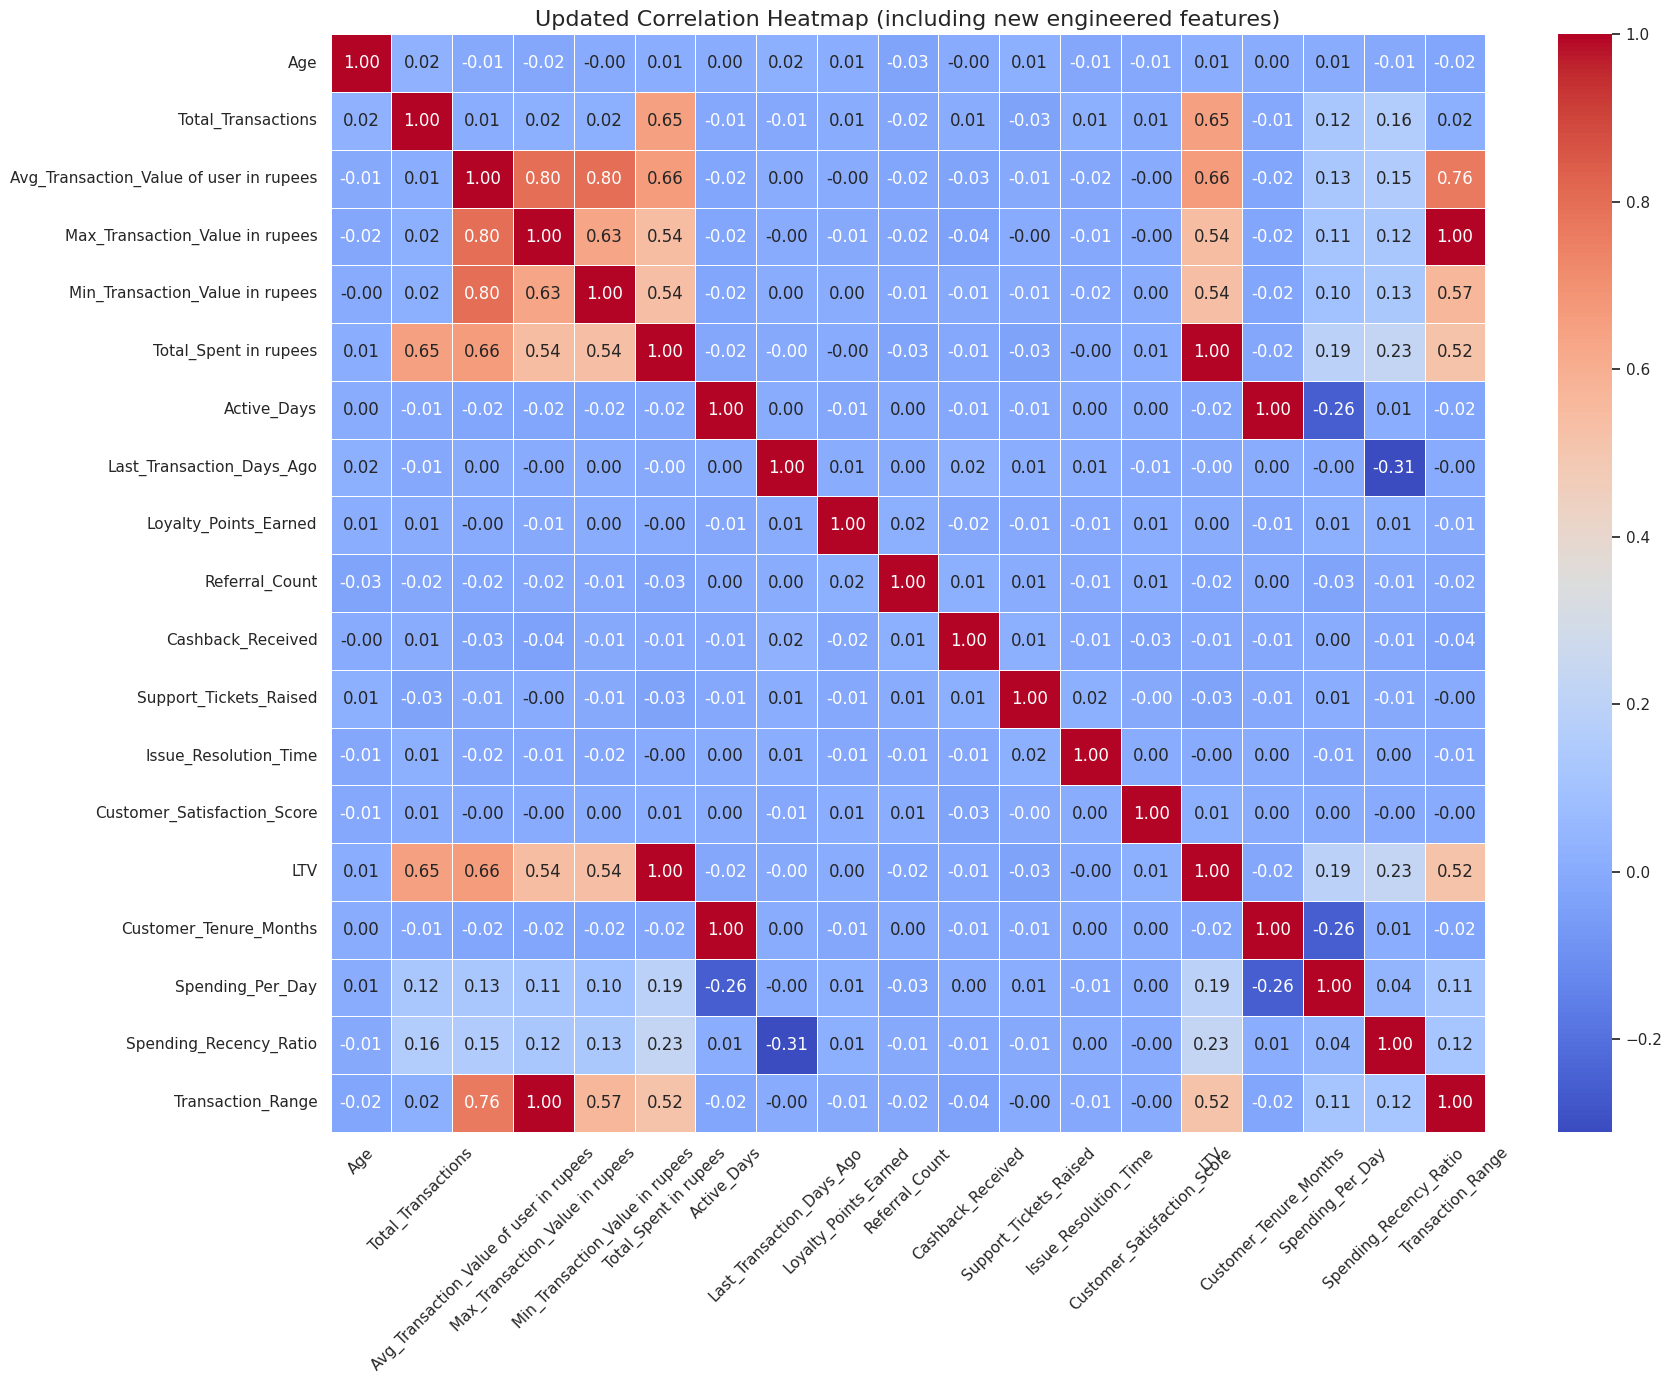

In [ ]:
#Updated Co-relation heatmap

plt.figure(figsize=(18, 14))

corr_matrix_updated = df_model.corr(numeric_only=True)

sns.heatmap(corr_matrix_updated, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Updated Correlation Heatmap (including new engineered features)', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
## Deciding to drop Total_spent_rupees--------Hence, trying to see if I can derive any more features with its essence

In [ ]:
### Adding more possible features
 # Support Sensitivity Score
 # Engagement Score
 # Transaction Frequency--------High fequency = More engaged customer

# Number of tickets * resolution time
df_model['Support_Sensitivity'] = df_model['Support_Tickets_Raised'] * df_model['Issue_Resolution_Time']

#  Loyalty Points + (Referral Count * 2)
df_model['Engagement_Score'] = df_model['Loyalty_Points_Earned'] + (df_model['Referral_Count'] * 2)

# Total Transactions / Tenure in Months
df_model['Transaction_Frequency'] = df_model['Total_Transactions'] / (df_model['Customer_Tenure_Months'] + 1e-6)  # small value to avoid division by 0


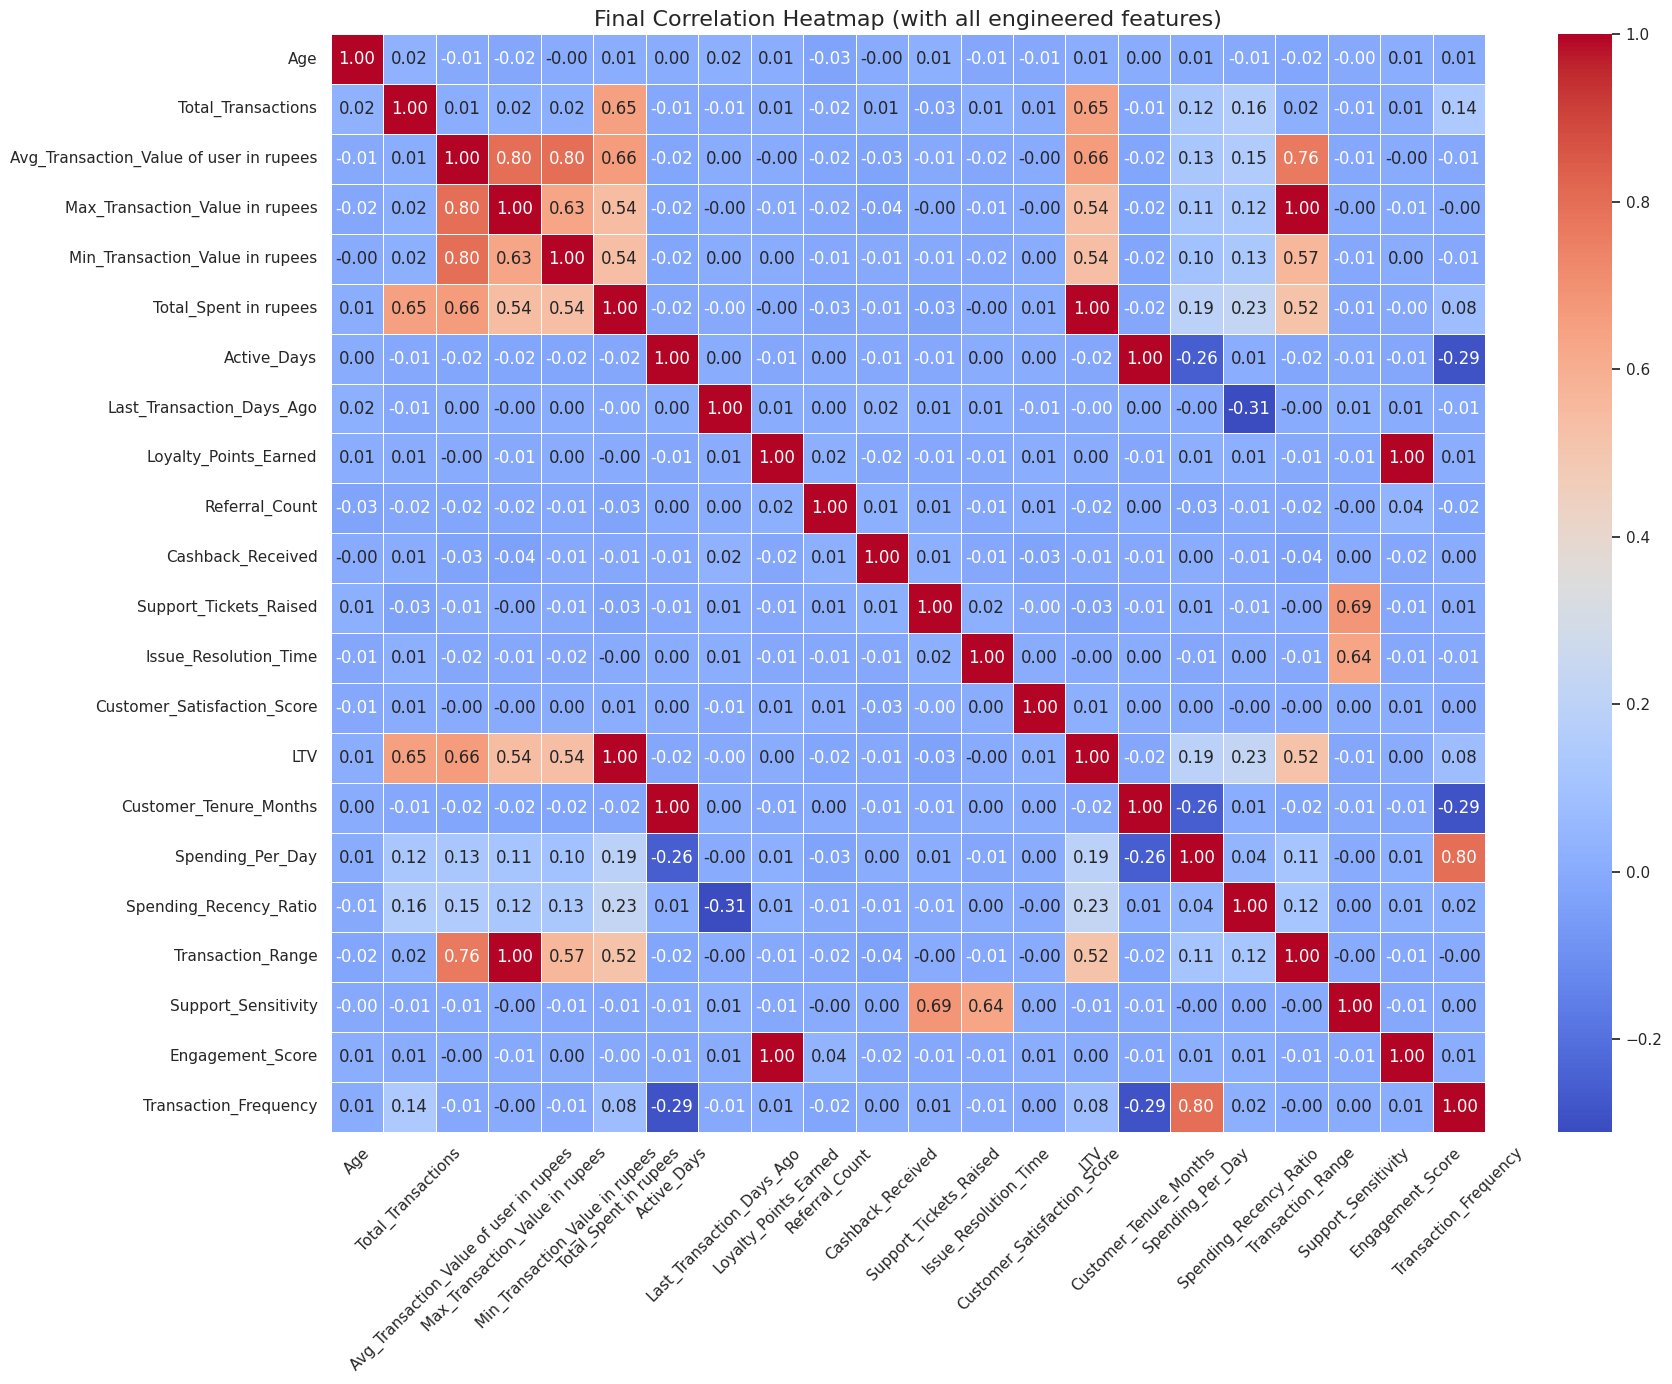

In [ ]:
##Again updated Co-relation matrix

# Updated correlation matrix for df_model
plt.figure(figsize=(18, 14))
corr_matrix_final = df_model.corr(numeric_only=True)

sns.heatmap(corr_matrix_final, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Final Correlation Heatmap (with all engineered features)', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
##There are Four Categorical Variables:
# Location
# Income Level
# App_Usage Frequency
# Payment method on the wallet

#Will box-plot each of them against LTV to see if the data shows a pattern attached to LTV with respect to different categories under these
# variables

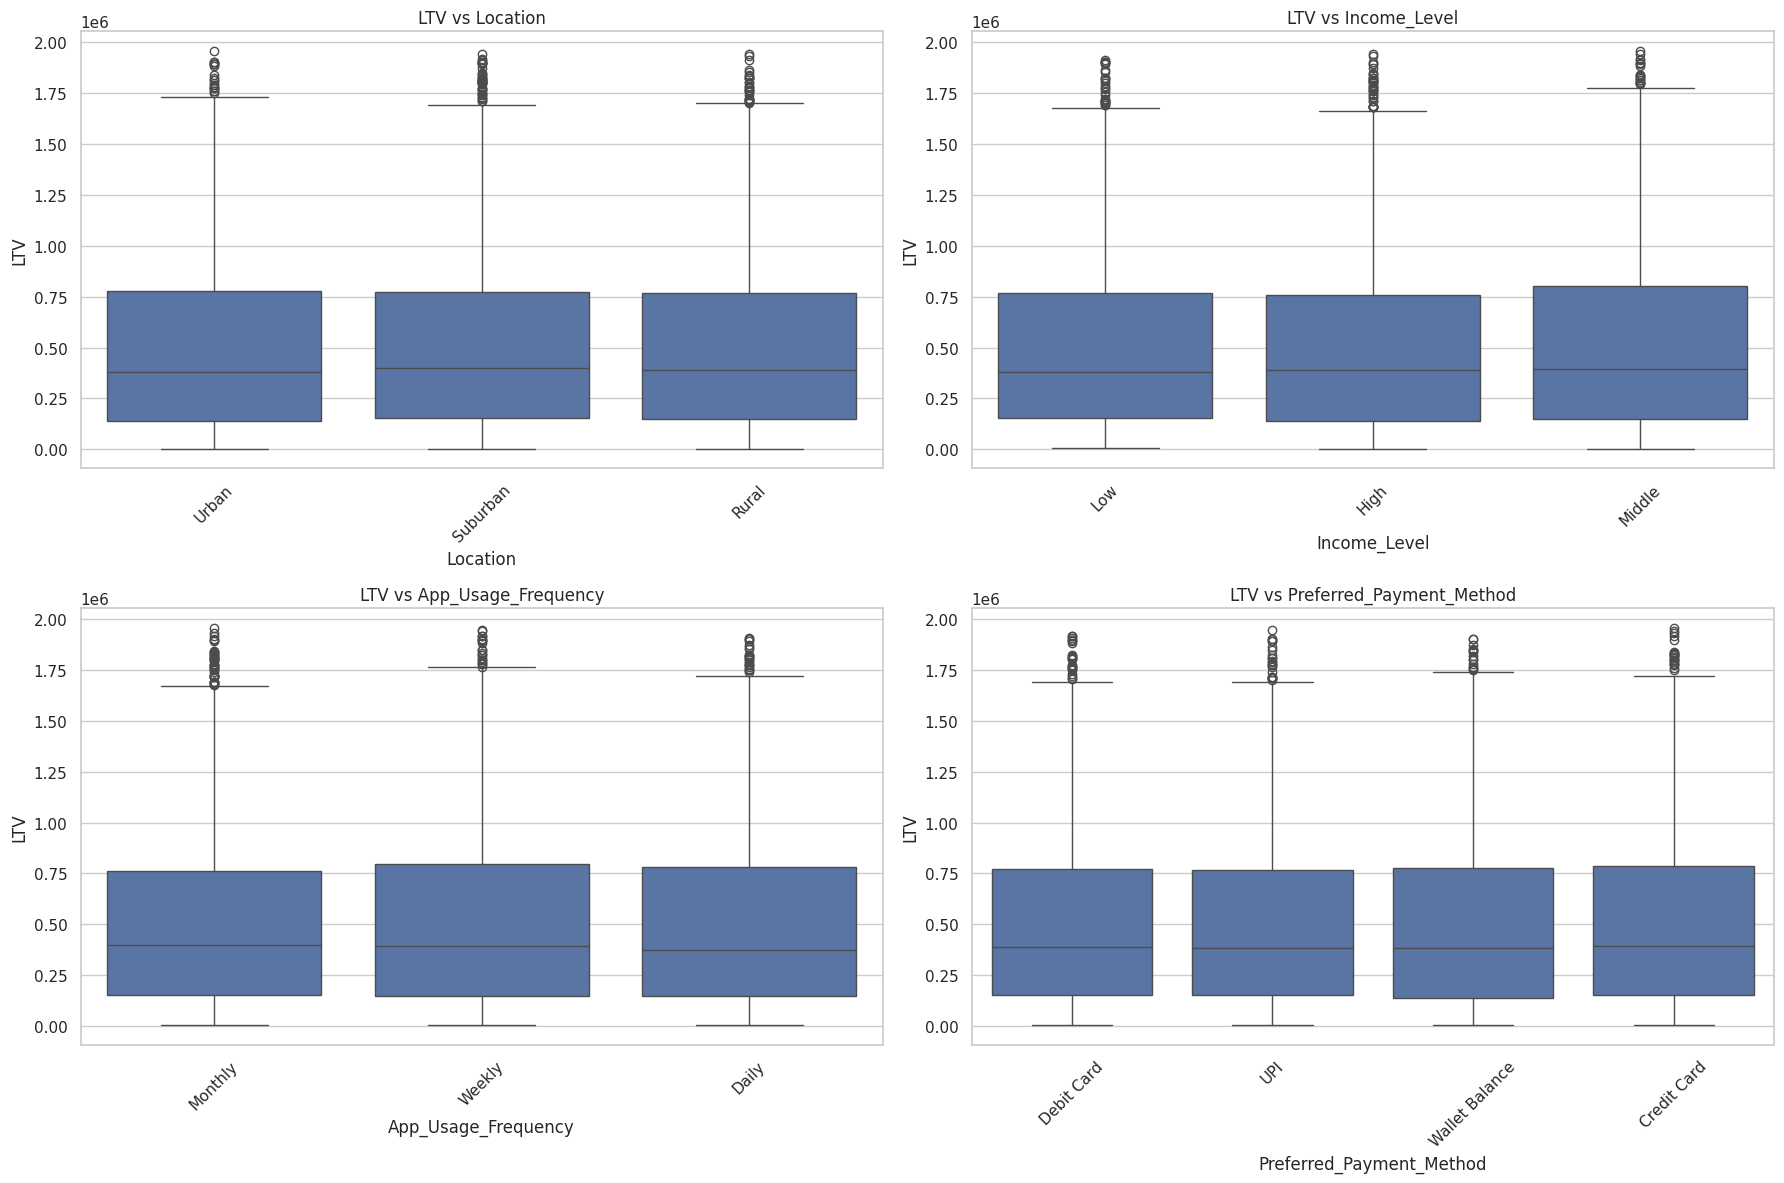

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# List of categorical columns to plot
categorical_cols = ['Location', 'Income_Level', 'App_Usage_Frequency', 'Preferred_Payment_Method']

# Create subplots
plt.figure(figsize=(18, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=col, y='LTV', data=df)
    plt.title(f'LTV vs {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# LTV Vs Location----> The median LTV across Urban, Suburban, and Rural locations is almost identical--->Low Impact on LTV,maybe very less predictive
# But has demographic reference to data---So keeping it--no harm

#LTV vs Income Level---> All three levels (Low, Middle, High) have similar medians and spread--->It's a weak predictor, but has a business reason to it
# ----So keeping it--no harm

#LTV vs App Usage frequency---> Very slight visual difference: Weekly users seem to have a slightly higher median LTV. But all 3 have similar spread
#  Low to moderate potential — might have latent behavior impact---So keeping it

#LTV Vs Preffered Payment method--->Its only a payment method and people here are already on the digital wallet platform--hence it does not matter
# Also, the distribution of people is very similar--no different payment method shows a pattern affctive the LTV.


In [ ]:
# Features to drop-----------------------NUMERIC(Original + Created)
features_to_drop = [
    'Max_Transaction_Value in rupees',
    'Transaction_Frequency',
    'Support_Sensitivity',
    'Engagement_Score',
    'Customer_Tenure_Months',
    'Issue_Resolution_Time',
    'Cashback_Received',
    'Referral_Count',
    'Loyalty_Points_Earned',
    'Last_Transaction_Days_Ago',
    'Active_Days',
    'Total_Spent in rupees'
]

df_model.drop(columns=features_to_drop, inplace=True)


In [ ]:
# Drop the 'Preferred_Payment_Method' column
df_model.drop(columns=['Preferred_Payment_Method'], inplace=True)


In [ ]:
## Initially we had 20 features including LTV
## We created 7 more (+7), then dropped "Customer_ID"(-1), then dropped 12 numeric and 1 categoric feature (-13)
## 20+7-1-13 = 13 FEATURES INLCUDING LTV as u see below

In [ ]:
df_model.head(5)

,Age,Location,Income_Level,Total_Transactions,Avg_Transaction_Value of user in rupees,Min_Transaction_Value in rupees,App_Usage_Frequency,Support_Tickets_Raised,Customer_Satisfaction_Score,LTV,Spending_Per_Day,Spending_Recency_Ratio,Transaction_Range
0,54,Urban,Low,192,16736.384023,6525.814861,Monthly,3,1,3.279546e+05,22952.755232,15301.836821,53691.019649
1,67,Suburban,High,979,14536.734683,2186.742245,Monthly,17,8,1.437053e+06,62146.127749,59051.714749,46163.358027
2,44,Urban,High,329,7061.372800,2743.406808,Monthly,11,4,2.419387e+05,31824.543168,105599.620512,29777.750379
3,30,Rural,High,71,16426.876453,4360.784994,Weekly,6,1,1.284599e+05,3900.696415,4078.000798,13467.111726
4,58,Urban,Middle,878,10800.092660,4532.872520,Daily,18,5,9.569514e+05,40180.005742,28734.791985,12964.762014


In [ ]:
## We have finalised our features for the model--Now Dummy encoding the categoric variables.
#Why?---- Because, dropping one category among possible categories in a categoric variable reduces multi-collinearity

In [ ]:
# List of categorical columns to encode
categorical_cols = ['Location', 'Income_Level', 'App_Usage_Frequency']

# One-hot encoding(here--dummy encoding) with drop_first to avoid dummy variable trap
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Check encoded column names
df_encoded.head()


,Age,Total_Transactions,Avg_Transaction_Value of user in rupees,Min_Transaction_Value in rupees,Support_Tickets_Raised,Customer_Satisfaction_Score,LTV,Spending_Per_Day,Spending_Recency_Ratio,Transaction_Range,Location_Suburban,Location_Urban,Income_Level_Low,Income_Level_Middle,App_Usage_Frequency_Monthly,App_Usage_Frequency_Weekly
0,54,192,16736.384023,6525.814861,3,1,3.279546e+05,22952.755232,15301.836821,53691.019649,False,True,True,False,True,False
1,67,979,14536.734683,2186.742245,17,8,1.437053e+06,62146.127749,59051.714749,46163.358027,True,False,False,False,True,False
2,44,329,7061.372800,2743.406808,11,4,2.419387e+05,31824.543168,105599.620512,29777.750379,False,True,False,False,True,False
3,30,71,16426.876453,4360.784994,6,1,1.284599e+05,3900.696415,4078.000798,13467.111726,False,False,False,False,False,True
4,58,878,10800.092660,4532.872520,18,5,9.569514e+05,40180.005742,28734.791985,12964.762014,False,True,False,True,False,False


In [ ]:
# DATA PRE-PROCESSING----EXPLORATORY DATA ANALYSIS----FEATURE ENGINERRING

# ALL DONE now---- Divide model into 80% Training and 20% Testing , then next is to do Normalisation(Scaling of numeric variables)

In [ ]:
## Scaling/ normalisation should be done on  the training data, Using  the same parameters (mean & std from train set), then on test data
#If we do it on entire dataset--there will be leakage, because I would
# have used the scaler on the future-testing data as well and it will not remain unseen

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Separating features and target
X = df_encoded.drop('LTV', axis=1)
y = df_encoded['LTV']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#  Initialize the scaler
scaler = StandardScaler()

#  Fit scaler only on training data and transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  print shapes to confirm
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

X_train shape: (5600, 15)
X_test shape: (1400, 15)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Step 1: Initialize and train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Step 2: Predict on test set
y_pred = model.predict(X_test_scaled)

# Step 3: Evaluate performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Step 4: Print results
print("Model Performance:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): ₹{mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ₹{rmse:,.2f}")


Model Performance:
R² Score: 0.8551
Mean Absolute Error (MAE): ₹125,471.33
Root Mean Squared Error (RMSE): ₹167,955.68


### Results Interpretation
**R2 **=  **85.5%**  ---- Means 85% variance in y can be explained by x---Proves my feature engineering, scaling outcome and choice of variables has been decent.

**MAE**  = On average, my model's LTV predictions are off by about ₹1.25 lakh. This is the typical error margin---Considering the wide range of LTV we have in the dataet.

**RMSE** =  This penalizes larger errors more — but it's still reasonable. Predictions are mostly close to actual values with limited large outliers.

RMSE value is 1 Lakh 67 thousand. **This may be due to LTV being extremely high in the dataset at some datapoints**.This may cause this. If we drop those, we may get a lesser RMSE.

#### **K-MEANS Clustering**

In [ ]:
## We have 'X' as the entire dataset's features(dropped LTV)---We will normalise it first and use our
## "model" which contains the linear regression model we built---to find predicted LTV for the entire dataframe

In [ ]:
predicted_ltv_all = model.predict(scaler.transform(X))

In [ ]:
# Show the first 10 predicted LTVs
print("Sample Predicted LTVs:")
print(predicted_ltv_all[:10])

Sample Predicted LTVs:
[ 540005.33092257 1197863.0277613   205403.46941538  384464.48433897
  924799.55069409  560895.30985262  880490.2541001  -336012.51629645
  757455.55907508  383702.92128535]


In [ ]:
## Creating 3 clusters--as we want to classify as "Low,Medium,High" Value
## Reshaping the 1D array beacuse we need 2D input for K-means

In [ ]:
from sklearn.cluster import KMeans

# Reshape predicted LTVs into a 2D array for KMeans
predicted_ltv_reshaped = predicted_ltv_all.reshape(-1, 1)

# Apply KMeans clustering with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(predicted_ltv_reshaped)

# Show first 10 cluster assignments
print("Cluster labels (first 10):", clusters[:10])


Cluster labels (first 10): [1 2 0 1 2 1 2 0 1 1]


In [ ]:
#How did the clustering work?

### K-Means randomly initialized 3 “centroids” (since n_clusters=3) — i.e., 3 values on the LTV scale.
### Assigned each customer’s Predicted_LTV to the nearest centroid
###Updated the centroid values by averaging LTVs in each group
###Repeated this until cluster assignments stabilized

# CORE PRINCIPLE: Each LTV is grouped with other LTVs that are closest in value (Euclidean distance) .

In [ ]:
## The mean LTV of each cluster is exactly equal to the final centroid value of that cluster after K-Means finishes training.

In [ ]:
import pandas as pd

# Create a new DataFrame with predicted LTV and cluster assignments
df_segments = pd.DataFrame({
    'Predicted_LTV': predicted_ltv_all,
    'Cluster': clusters
})

# Preview
print(df_segments.head())


   Predicted_LTV  Cluster
0   5.400053e+05        1
1   1.197863e+06        2
2   2.054035e+05        0
3   3.844645e+05        1
4   9.247996e+05        2


In [ ]:
# Step 1: Calculate centroid/average predicted LTV for each cluster
cluster_avg = df_segments.groupby('Cluster')['Predicted_LTV'].mean().sort_values().reset_index()

# Step 2: Assign business-friendly segment labels
cluster_avg['Segment'] = ['Low-value', 'Medium-value', 'High-value']

# Show results
print("Cluster Centroids and Segment Labels:")
print(cluster_avg)


Cluster Centroids and Segment Labels:
   Cluster  Predicted_LTV       Segment
0        0   1.761235e+04     Low-value
1        1   5.207925e+05  Medium-value
2        2   1.017045e+06    High-value


In [ ]:
## Visulalising the Orginal "Customer ID" + Original LTV in dataset + Predicted LTV(for entire) + Cluster segment in which it falls


#  Create final DataFrame with all key info
df_segments_full = pd.DataFrame({
    'Customer_ID': df['Customer_ID'].values,       # from original df
    'Actual_LTV': df['LTV'].values,                # original target
    'Predicted_LTV': predicted_ltv_all,            # from regression
    'Cluster': clusters                            # from K-Means
})

#  Merge segment labels based on cluster
df_segments_full = df_segments_full.merge(
    cluster_avg[['Cluster', 'Segment']], on='Cluster', how='left'
)

#  Preview
print(df_segments_full.head())


  Customer_ID    Actual_LTV  Predicted_LTV  Cluster       Segment
0   cust_0000  3.279546e+05   5.400053e+05        1  Medium-value
1   cust_0001  1.437053e+06   1.197863e+06        2    High-value
2   cust_0002  2.419387e+05   2.054035e+05        0     Low-value
3   cust_0003  1.284599e+05   3.844645e+05        1  Medium-value
4   cust_0004  9.569514e+05   9.247996e+05        2    High-value


In [ ]:
### Customers whose Predicted_LTV is closest to ₹17.6k → Cluster 0
###Closest to ₹5.2L → Cluster 1
###Closest to ₹10.17L → Cluster 2

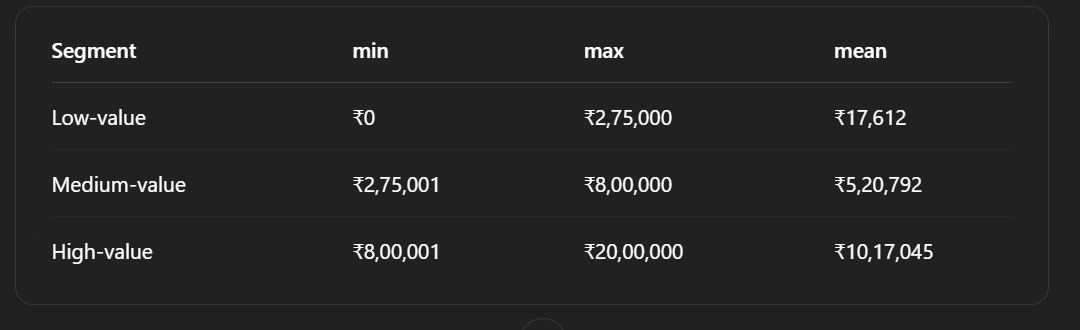